# GMP AI 실습 — 전체 커리큘럼 (10개 예제)

## 5개 학습 모듈

| 모듈 | # | 주제 | 난이도 | GMP 핵심 규정 | AI 기법 |
|:----:|:--:|------|:------:|-------------|--------|
| **① 기초·탐색** | 1 | 품질 데이터 탐색 (EDA) | ⭐ | ICH Q8 QbD · CQA/CPP 파악 | EDA · 상관분석 · 시각화 |
| | 2 | SPC 관리도 | ⭐⭐ | ICH Q10 PQS · PAT 연속 모니터링 | Shewhart · CUSUM · EWMA |
| **② 예측적 품질관리** | 3 | OOS 발생 예측 | ⭐⭐⭐ | 21 CFR 211.192 OOS 조사 | Random Forest 분류 |
| | 4 | 공정 이상 탐지 | ⭐⭐⭐ | ICH Q9 품질 리스크 관리 | Isolation Forest |
| **③ QMS 자동화** | 5 | Deviation 자동 분류 | ⭐⭐⭐⭐ | ICH Q10 CAPA · GDP | K-Means 클러스터링 |
| | 6 | CAPA 효과성 예측 | ⭐⭐⭐⭐ | 21 CFR 820.100 · ICH Q10 | Gradient Boosting |
| **④ 공정 모니터링** | 7 | 시계열 공정 상태 패턴 인식 | ⭐⭐⭐⭐ | FDA PAT · GMP Annex 11 | Conv1D CNN |
| | 8 | 설비 예지보수 (PdM) | ⭐⭐⭐⭐⭐ | EU GMP Annex 1 · GAMP 5 | LSTM · RUL 회귀 |
| **⑤ 케이스 스터디** | 9 | 페니실린 공정데이터탐색 (실제 데이터) | ⭐⭐⭐ | ICH Q8 CPP/CQA · ALCOA+ | EDA · 다변량 분석 |
| | 10 | 페니실린 소프트센서·RTRT (실제 데이터) | ⭐⭐⭐⭐⭐ | PAT 소프트센서 · RTRT | RF · 시계열 예측 |

> 💡 **학습 흐름**: 모듈①(데이터 기초) → ②(예측 모델) → ③(QMS 자동화) → ④(시계열·딥러닝) → ⑤(실데이터 종합)  
> 예제 9·10은 동일한 IndPenSim 실제 발효 데이터를 사용하는 **케이스 스터디 쌍**입니다.

## ⚙️ 공통 환경 설정 (가장 먼저 실행하세요!)

In [1]:
# =====================================================
# 공통 설정: 모든 예제에서 사용하는 라이브러리 한 번에 설치/로드
# =====================================================

# ── Colab 한글 폰트 설치 ──
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 필요한 라이브러리 불러오기 ──
import numpy as np              # 수치 계산
import pandas as pd             # 데이터 표(DataFrame) 처리
import matplotlib.pyplot as plt # 그래프 그리기
import seaborn as sns           # 고급 통계 그래프
import warnings
warnings.filterwarnings('ignore')


print("✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.")
print(f"   NumPy  버전: {np.__version__}")
print(f"   Pandas 버전: {pd.__version__}")


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (30.8 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.
   NumPy  버전: 2.0.2
   Pandas 버전: 2.2.2


---
## 예제 2: 관리도(SPC)를 이용한 공정 모니터링 ⭐⭐ 초중급

### 🏭 배경 설명

**통계적 공정관리(SPC, Statistical Process Control)**는 GMP 환경에서 공정의 안정성을
실시간으로 모니터링하는 핵심 도구입니다. FDA의 PAT(Process Analytical Technology) 가이드라인과
ICH Q10 의약품 품질시스템에서 SPC 적용을 권고하고 있습니다.

관리도의 핵심 개념:
- **CL (Center Line):** 중심선 = 공정 평균
- **UCL (Upper Control Limit):** 상부 관리한계 = 평균 + 3σ  
- **LCL (Lower Control Limit):** 하부 관리한계 = 평균 - 3σ
- **OOT (Out of Trend):** 관리한계를 벗어난 추세 이상
- **Cp (공정능력지수):** (USL-LSL) / 6σ, 값이 클수록 안정적인 공정

**이 예제에서 배우는 것:**
- Python으로 X-bar 관리도 구현
- 관리한계 자동 계산 및 시각화
- Western Electric 규칙(연속 7점 규칙) 기반 이상 신호 탐지
- Drift(평균 이동)와 산포 증가 패턴 구분

**가상 시나리오:** 무균주사제 충전라인의 충전량(mL) 연속 모니터링 데이터를 분석합니다.


---
## 📍 모듈 ① — 기초·탐색 | 예제 2: SPC 관리도

### 🏛️ GMP 커버리지
| 규정 / 가이드라인 | 이 예제에서의 적용 |
|----------------|-----------------|
| **ICH Q10 의약품 품질 시스템** | Continual Process Verification — 공정 통계 관리 요구 |
| **FDA PAT Guidance (2004)** | 연속 공정 모니터링 도구로 관리도 명시 |
| **21 CFR 211.68** | 공정 데이터의 자동 기록·모니터링 시스템 |
| **ICH Q8(R2) Design Space** | 관리도의 UCL/LCL = 허용 공정 범위(Normal Operating Range) |

### 🤖 AI 도입 장점
| 전통 방법 | AI / 데이터 과학 방법 | 개선 효과 |
|---------|-------------------|---------|
| 단변량 Shewhart 관리도 (변수 1개씩) | **다변량 관리도** (Hotelling T²) 로 변수 간 상호작용 감지 | 놓치던 이상 패턴 탐지 |
| 수동 규칙(Nelson 8가지) 확인 | 머신러닝 기반 OOT(Out-of-Trend) 자동 감지 | 실시간 경보 자동화 |
| 정규분포 가정 필수 | 비모수 기법·딥러닝으로 비정규 분포 처리 가능 | 적용 범위 확장 |

### 🎯 핵심 Takeaway
> **"AI는 SPC를 대체하지 않는다 — AI는 SPC를 다변량·실시간·자동화로 확장한다."**

1. 관리도의 UCL/LCL은 통계적 공정 능력이지, 규격(Specification)이 아님 — 혼동 금지
2. SPC의 한계(단변량, 정규분포 가정)를 극복하는 것이 **다변량 통계 공정 관리(MSPC)**의 역할
3. PAT Framework에서 SPC는 **공정 모니터링**의 기본 도구 → AI는 그 위에 올라타는 지능

### ➡️ 다음 예제
**예제 3 (OOS 예측)**: 관리도로 감지한 이상 신호를 **머신러닝으로 OOS 발생 전에 예측**

In [2]:
# =====================================================
# 예제 2: 관리도(SPC)를 이용한 공정 모니터링
# =====================================================

# ─────────────────────────────────────────────────────
# 2-1. 무균주사제 충전량 데이터 생성
# 세 가지 공정 단계를 시뮬레이션합니다:
#   ① 정상 공정 (100포인트): 목표값 5.00mL, 안정적
#   ② Drift 발생 (30포인트): 평균이 5.10mL로 서서히 이동
#   ③ 산포 불안정 (20포인트): 평균은 유지되지만 산포가 2배로 증가
# ─────────────────────────────────────────────────────

np.random.seed(2024)

# 각 단계별 데이터 생성
normal_data   = np.random.normal(5.00, 0.05, 100)  # 정상 공정
drift_data    = np.random.normal(5.10, 0.05,  30)  # 평균 이동 (Drift)
unstable_data = np.random.normal(5.00, 0.10,  20)  # 산포 증가 (불안정)

# 세 데이터를 이어 붙이기 (concatenate = 연결)
fill_volume = np.concatenate([normal_data, drift_data, unstable_data])

# 데이터프레임 생성
df_spc = pd.DataFrame({
    'time_min'   : np.arange(len(fill_volume)) * 10,  # 10분 간격으로 측정
    'fill_vol_mL': fill_volume,
    'phase'      : ['정상']*100 + ['Drift']*30 + ['불안정']*20  # 단계 라벨
})

print(f"📊 충전량 데이터 생성 완료: 총 {len(df_spc)}개 측정점")
print(f"   총 측정 시간: {df_spc['time_min'].max() // 60:.0f}시간 {df_spc['time_min'].max() % 60:.0f}분")
df_spc.head()


📊 충전량 데이터 생성 완료: 총 150개 측정점
   총 측정 시간: 24시간 50분


,time_min,fill_vol_mL,phase
0,0,5.083402,정상
1,10,5.036867,정상
2,20,4.989923,정상
3,30,4.992454,정상
4,40,5.045803,정상


In [3]:
# ─────────────────────────────────────────────────────
# 2-2. 관리한계 계산 (정상 공정 100개 데이터 기준)
# ─────────────────────────────────────────────────────

# 관리한계는 반드시 '정상 상태'의 데이터로부터 계산합니다
baseline = df_spc[df_spc['phase'] == '정상']['fill_vol_mL']

CL  = baseline.mean()          # 중심선: 공정 평균
sig = baseline.std()           # 공정 표준편차 (σ, sigma)

# 3-시그마 관리한계 계산
UCL = CL + 3 * sig             # 상부 관리한계
LCL = CL - 3 * sig             # 하부 관리한계
UWL = CL + 2 * sig             # 상부 경고한계 (2σ)
LWL = CL - 2 * sig             # 하부 경고한계 (2σ)

# 제품 규격 한계 (사전에 정해진 값)
USL, LSL = 5.20, 4.80          # 상부/하부 규격한계 (mL)

# 공정능력지수 계산
Cp = (USL - LSL) / (6 * sig)   # 규격 폭 / 공정 폭

print("=" * 50)
print("📏 관리한계 계산 결과")
print("=" * 50)
print(f"  중심선  (CL)  : {CL:.4f} mL")
print(f"  표준편차 (σ)  : {sig:.4f} mL")
print(f"  상부관리한계 (UCL) : {UCL:.4f} mL")
print(f"  하부관리한계 (LCL) : {LCL:.4f} mL")
print(f"  상부규격한계 (USL) : {USL:.4f} mL")
print(f"  하부규격한계 (LSL) : {LSL:.4f} mL")
print(f"\n  공정능력지수 (Cp)  : {Cp:.2f}")
print()

# Cp 값에 따른 공정 능력 해석
if   Cp >= 1.67: print("  ✅ Cp ≥ 1.67 : 탁월한 공정 능력 (6 Sigma 수준)")
elif Cp >= 1.33: print("  ✅ Cp ≥ 1.33 : 충분한 공정 능력 (FDA 권고 수준)")
elif Cp >= 1.00: print("  ⚠️  Cp ≥ 1.00 : 공정 능력 부족, 개선 권고")
else:            print("  🚨 Cp < 1.00 : 공정 능력 불량, 즉각 조치 필요")


📏 관리한계 계산 결과
  중심선  (CL)  : 5.0015 mL
  표준편차 (σ)  : 0.0499 mL
  상부관리한계 (UCL) : 5.1513 mL
  하부관리한계 (LCL) : 4.8517 mL
  상부규격한계 (USL) : 5.2000 mL
  하부규격한계 (LSL) : 4.8000 mL

  공정능력지수 (Cp)  : 1.33

  ✅ Cp ≥ 1.33 : 충분한 공정 능력 (FDA 권고 수준)


### 💡 공정능력지수(Cp)의 상세 의미와 권고 기준

**1. Cp의 정의와 수식**
$$Cp = \frac{USL - LSL}{6\sigma}$$
*   **의미:** 공정의 '잠재적' 능력입니다. 규격의 폭($USL-LSL$)을 공정의 실제 변동 폭($6\sigma$)으로 나눈 값입니다.
*   **비유:** 규격은 '주차장 칸의 너비'이고, 공정 변동은 '자동차의 너비'입니다. Cp가 클수록 주차하기(품질 유지)가 쉽습니다.

**2. 주요 권고 수치 및 등급**

| Cp 값 | 등급 | 의미 및 권고 사항 |
| :--- | :--- | :--- |
| **Cp ≥ 1.67** | 1등급 | **탁월 (6-Sigma 수준):** 공정이 매우 안정적이며 부적합 발생 가능성이 거의 없음 |
| **Cp ≥ 1.33** | 2등급 | **충분 (FDA/의약품 권고):** 신규 공정이나 일반적인 GMP 공정에서 요구되는 표준 수치 |
| **1.33 > Cp ≥ 1.00** | 3등급 | **보통:** 공정이 규격 내에 있으나, 변동이 조금만 커져도 부적합(OOS) 위험이 있음 |
| **Cp < 1.00** | 4등급 | **부족:** 공정 변동이 규격 폭보다 커서 부적합품 발생이 불가피함 (즉각 개선 필요) |

**3. 왜 1.33인가?**
*   FDA 및 산업계에서 **1.33**을 강조하는 이유는 $4\sigma$ 수준의 관리를 의미하기 때문입니다.
*   Cp가 1.33이면 양쪽 규격 한계와 평균 사이에 약 $4\sigma$의 여유가 있어, 공정 평균이 미세하게 흔들리더라도 즉각적인 불량이 발생하지 않는 최소한의 '안전 마진'을 확보한 것으로 간주합니다.

**4. 주의사항 (Cp vs Cpk)**
*   **Cp:** 공정의 평균이 규격의 정중앙에 있다고 가정할 때의 능력입니다.
*   **Cpk:** 실제 공정 평균이 한쪽으로 치우친 것까지 반영한 지수입니다. GMP 현장에서는 실제 능력을 보기 위해 **Cpk**를 더 중요하게 확인합니다.

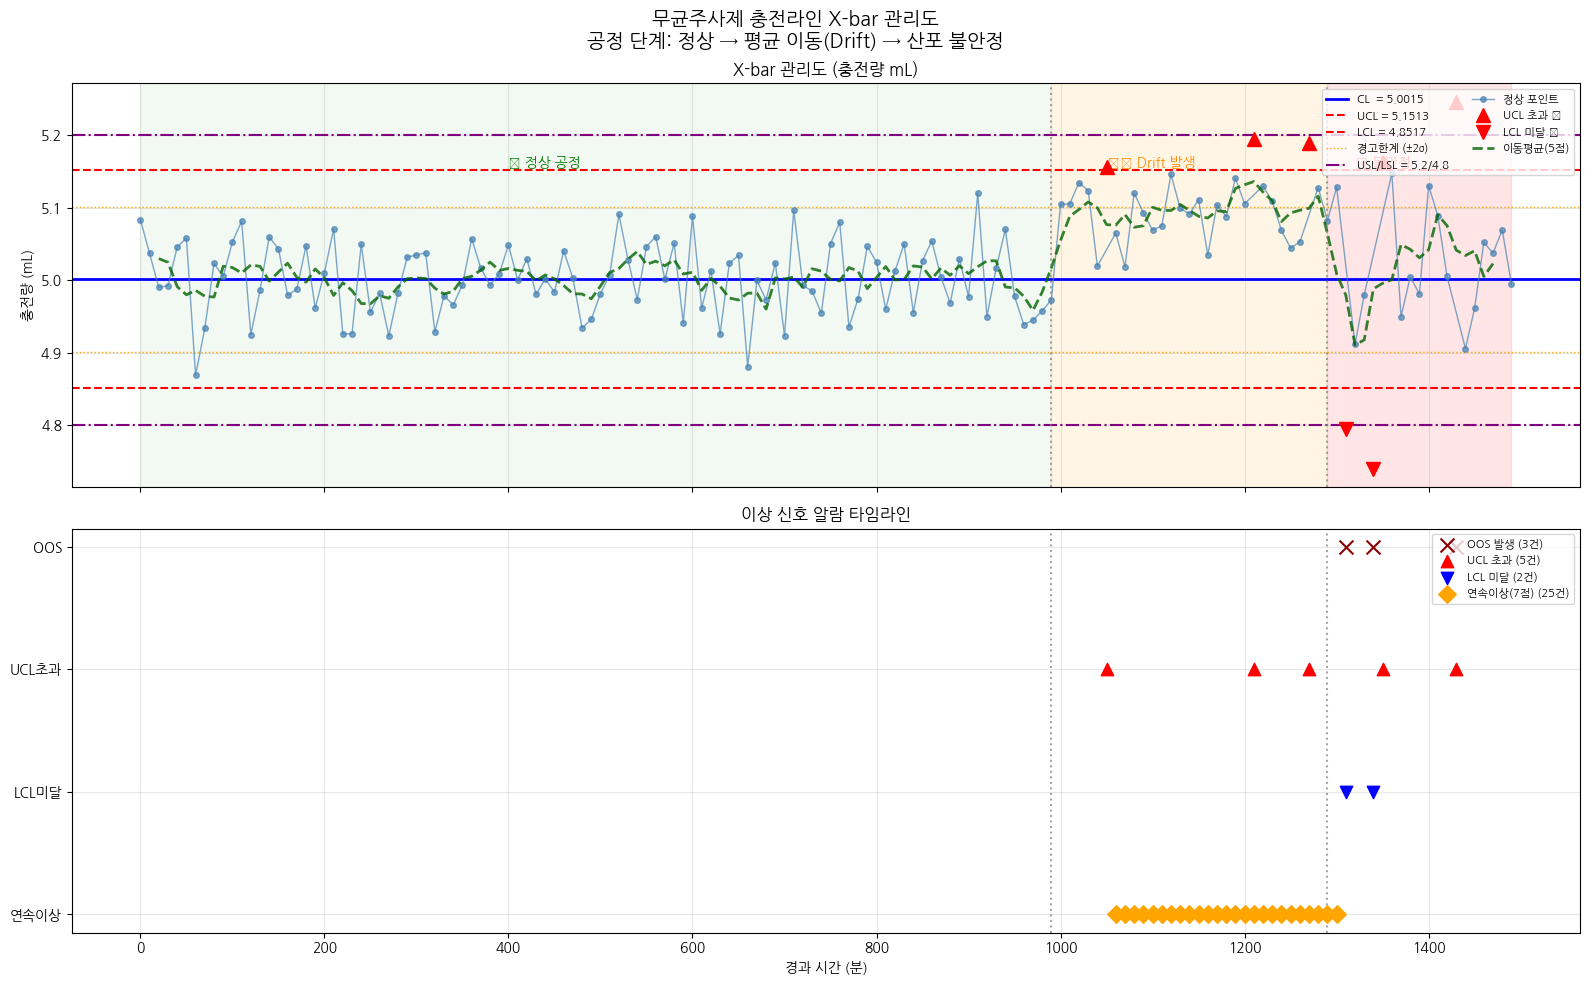


✅ 예제 2 완료!
  탐지된 이상 신호: UCL초과 5건, OOS 3건, 연속이상 25건
📌 핵심 인사이트: 관리도는 OOS가 발생하기 전에 Drift를 미리 감지하여 예방 조치를 가능하게 합니다.


In [4]:
# ─────────────────────────────────────────────────────
# 2-3. 이상 신호 탐지 및 관리도 시각화
# ─────────────────────────────────────────────────────

data = df_spc['fill_vol_mL'].values   # 충전량 데이터를 배열로 변환

# ── 이상 신호 플래그 생성 ──
df_spc['alarm_UCL'] = data > UCL       # UCL 초과 여부
df_spc['alarm_LCL'] = data < LCL       # LCL 미달 여부
df_spc['alarm_OOS'] = (data > USL) | (data < LSL)   # OOS 여부

# 이동평균 (최근 5포인트): 추세를 부드럽게 보여줌
df_spc['moving_avg'] = df_spc['fill_vol_mL'].rolling(window=5, center=True).mean()

# 연속 7점 규칙: 중심선 한쪽으로 7개 연속 → 공정 이상 신호
df_spc['run_signal'] = False
for i in range(6, len(df_spc)):
    window_7 = data[i-6:i+1]           # 최근 7개 포인트
    if all(window_7 > CL) or all(window_7 < CL):    # 전부 위 또는 전부 아래
        df_spc.loc[i, 'run_signal'] = True

# ── 관리도 그리기 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('무균주사제 충전라인 X-bar 관리도\n공정 단계: 정상 → 평균 이동(Drift) → 산포 불안정',
             fontsize=14, fontweight='bold')

x = df_spc['time_min']
y = df_spc['fill_vol_mL']

# ━━━ 상단: X-bar 관리도 ━━━
ax1.set_title('X-bar 관리도 (충전량 mL)', fontsize=12)

# 구간 배경색 (공정 단계별 구분)
ax1.axvspan(  0,  990, alpha=0.05, color='green')   # 정상 구간
ax1.axvspan(990, 1290, alpha=0.10, color='orange')  # Drift 구간
ax1.axvspan(1290,1490, alpha=0.10, color='red')     # 불안정 구간

# 관리한계선 그리기
ax1.axhline(CL,  color='blue',   lw=2,   ls='-',  label=f'CL  = {CL:.4f}')
ax1.axhline(UCL, color='red',    lw=1.5, ls='--', label=f'UCL = {UCL:.4f}')
ax1.axhline(LCL, color='red',    lw=1.5, ls='--', label=f'LCL = {LCL:.4f}')
ax1.axhline(UWL, color='orange', lw=1,   ls=':',  label='경고한계 (±2σ)')
ax1.axhline(LWL, color='orange', lw=1,   ls=':')
ax1.axhline(USL, color='purple', lw=1.5, ls='-.', label=f'USL/LSL = {USL}/{LSL}')
ax1.axhline(LSL, color='purple', lw=1.5, ls='-.')

# 데이터 포인트 (정상: 파란 원, 이상: 빨간 삼각형)
normal_mask = ~(df_spc['alarm_UCL'] | df_spc['alarm_LCL'])
ax1.plot(x[normal_mask], y[normal_mask], 'o-', color='steelblue',
         ms=4, lw=1, alpha=0.7, label='정상 포인트')
ax1.plot(x[df_spc['alarm_UCL']], y[df_spc['alarm_UCL']],
         '^', color='red', ms=10, zorder=5, label='UCL 초과 🚨')
ax1.plot(x[df_spc['alarm_LCL']], y[df_spc['alarm_LCL']],
         'v', color='red', ms=10, zorder=5, label='LCL 미달 🚨')
ax1.plot(x, df_spc['moving_avg'], '--', color='darkgreen', lw=2, alpha=0.8, label='이동평균(5점)')

ax1.set_ylabel('충전량 (mL)')
ax1.legend(loc='upper right', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# 구간 주석
ax1.text(400,  UCL+0.005, '✅ 정상 공정',   fontsize=10, color='green')
ax1.text(1050, UCL+0.005, '⚠️ Drift 발생',  fontsize=10, color='darkorange')
ax1.text(1320, UCL+0.005, '🚨 불안정',      fontsize=10, color='red')

# ━━━ 하단: 알람 타임라인 ━━━
ax2.set_title('이상 신호 알람 타임라인', fontsize=12)

# 각 알람 유형을 다른 높이(y값)에 표시
alarm_types = [
    (df_spc['alarm_OOS'],  3, 'darkred',  'x',   100, 'OOS 발생'),
    (df_spc['alarm_UCL'],  2, 'red',      '^',    80, 'UCL 초과'),
    (df_spc['alarm_LCL'],  1, 'blue',     'v',    80, 'LCL 미달'),
    (df_spc['run_signal'], 0, 'orange',   'D',    80, '연속이상(7점)'),
]
for mask, y_pos, color, marker, size, label in alarm_types:
    if mask.sum() > 0:
        ax2.scatter(x[mask], [y_pos] * mask.sum(), c=color, s=size,
                    marker=marker, zorder=5, label=f'{label} ({mask.sum()}건)')

ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(['연속이상', 'LCL미달', 'UCL초과', 'OOS'])
ax2.set_xlabel('경과 시간 (분)')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

# 구간 구분선
for ax in [ax1, ax2]:
    ax.axvline(990,  color='gray', ls=':', alpha=0.7)
    ax.axvline(1290, color='gray', ls=':', alpha=0.7)

plt.tight_layout()
plt.savefig('예제2_SPC관리도.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 예제 2 완료!")
print(f"  탐지된 이상 신호: UCL초과 {df_spc['alarm_UCL'].sum()}건, OOS {df_spc['alarm_OOS'].sum()}건, 연속이상 {df_spc['run_signal'].sum()}건")
print("📌 핵심 인사이트: 관리도는 OOS가 발생하기 전에 Drift를 미리 감지하여 예방 조치를 가능하게 합니다.")


---
## ✅ 예제 2 핵심 요약

| 항목 | 내용 |
|------|------|
| **GMP 적용** | ICH Q10 · FDA PAT — 연속 공정 모니터링 |
| **AI 기법** | Shewhart 관리도 · CUSUM · EWMA (전통 + 다변량 확장) |
| **핵심 성과** | OOT 패턴 조기 탐지, 공정 능력(Cp/Cpk) 정량화 |
| **다음 단계** | 관리도 경보 → 예제 3(OOS 예측)으로 불합격 사전 차단 |

> 💡 **기억할 한 줄**: "SPC의 관리한계(Control Limit)와 품질규격(Specification)을 혼동하지 말 것 — 전자는 공정, 후자는 제품 기준이다." 